<a href="https://colab.research.google.com/github/Riteshpaul3/Brain-Tumor-Detection-Python-/blob/main/Shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import cv2
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf

# Define constants
image_size = 150
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']
X_data = []
Y_data = []

# Use generator-style approach to avoid loading all at once
def load_images_in_batches(base_path, labels, image_size, max_images_per_class=500):
    X = []
    Y = []
    for label in labels:
        count = 0
        for folder in ['Training', 'Testing']:
            folder_path = os.path.join(base_path, folder, label)
            files = os.listdir(folder_path)
            for file in files:
                if count >= max_images_per_class:
                    break
                img_path = os.path.join(folder_path, file)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.resize(img, (image_size, image_size))
                    X.append(img / 255.0)  # Normalize on the fly
                    Y.append(labels.index(label))
                    count += 1
    return np.array(X, dtype=np.float32), tf.keras.utils.to_categorical(Y, num_classes=len(labels))

# Path to your dataset
base_path = '/content/drive/MyDrive/Brain tumar'

# Load limited number of images per class to avoid RAM crash
X_data, Y_data = load_images_in_batches(base_path, labels, image_size, max_images_per_class=500)

In [ ]:
X_data, Y_data = shuffle(X_data, Y_data, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_data, Y_data, test_size=0.1, random_state=42)

In [ ]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.3))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Dropout(0.3))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.3))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.3))
model.add(Conv2D(128, (3, 3), activation='relu', name='last_conv'))  # Name this for Grad-CAM
model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(4, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 146, 146, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 69, 69, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 69, 69, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,447,044 (16.96 MB)

 Trainable params: 4,447,044 (16.96 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 346s 7s/step - accuracy: 0.2338 - loss: 1.4355 - val_accuracy: 0.4556 - val_loss: 1.1917
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 388s 7s/step - accuracy: 0.3297 - loss: 1.2962 - val_accuracy: 0.2444 - val_loss: 1.3873
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 379s 7s/step - accuracy: 0.2521 - loss: 1.3859 - val_accuracy: 0.2333 - val_loss: 1.3870
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 378s 7s/step - accuracy: 0.2544 - loss: 1.3865 - val_accuracy: 0.2611 - val_loss: 1.3866
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 379s 7s/step - accuracy: 0.2311 - loss: 1.3863 - val_accuracy: 0.2444 - val_loss: 1.3866
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 383s 7s/step - accuracy: 0.2493 - loss: 1.3862 - val_accuracy: 0.2333 - val_loss: 1.3825
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 337s 7s/step - accuracy: 0.3120 - loss: 1.3205 - val_accuracy: 0.5500 - val_loss: 1.0913
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 383s 7s/step - accuracy: 0.5353 - loss: 1.0120 - val_accuracy: 0.7444 - v

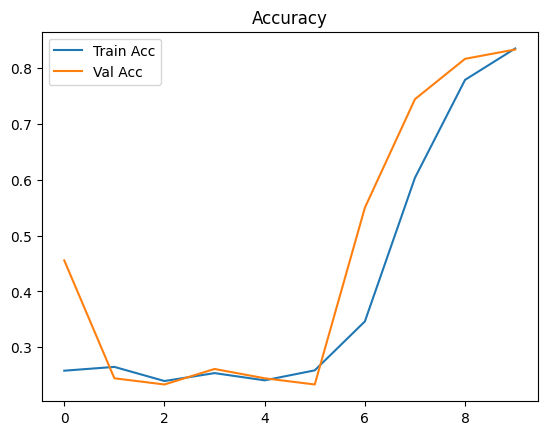

In [ ]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()

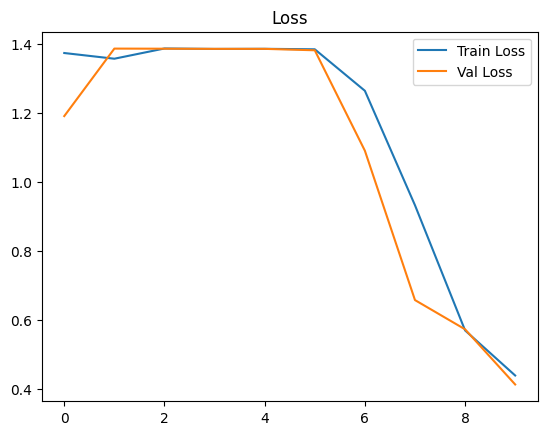

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
# === 8. Install and Use SHAP ===
!pip install shap
import shap
from shap.maskers import Image as shap_Image

# Prepare background and test samples for SHAP
background = X_train[np.random.choice(X_train.shape[0], 50, replace=False)]
test_images = X_test[:5]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  20%|██        | 1/5 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  60%|██████    | 3/5 [01:44<00:47, 23.58s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  80%|████████  | 4/5 [02:32<00:33, 33.86s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 5/5 [03:22<00:00, 39.73s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 6it [04:10, 50.07s/it]


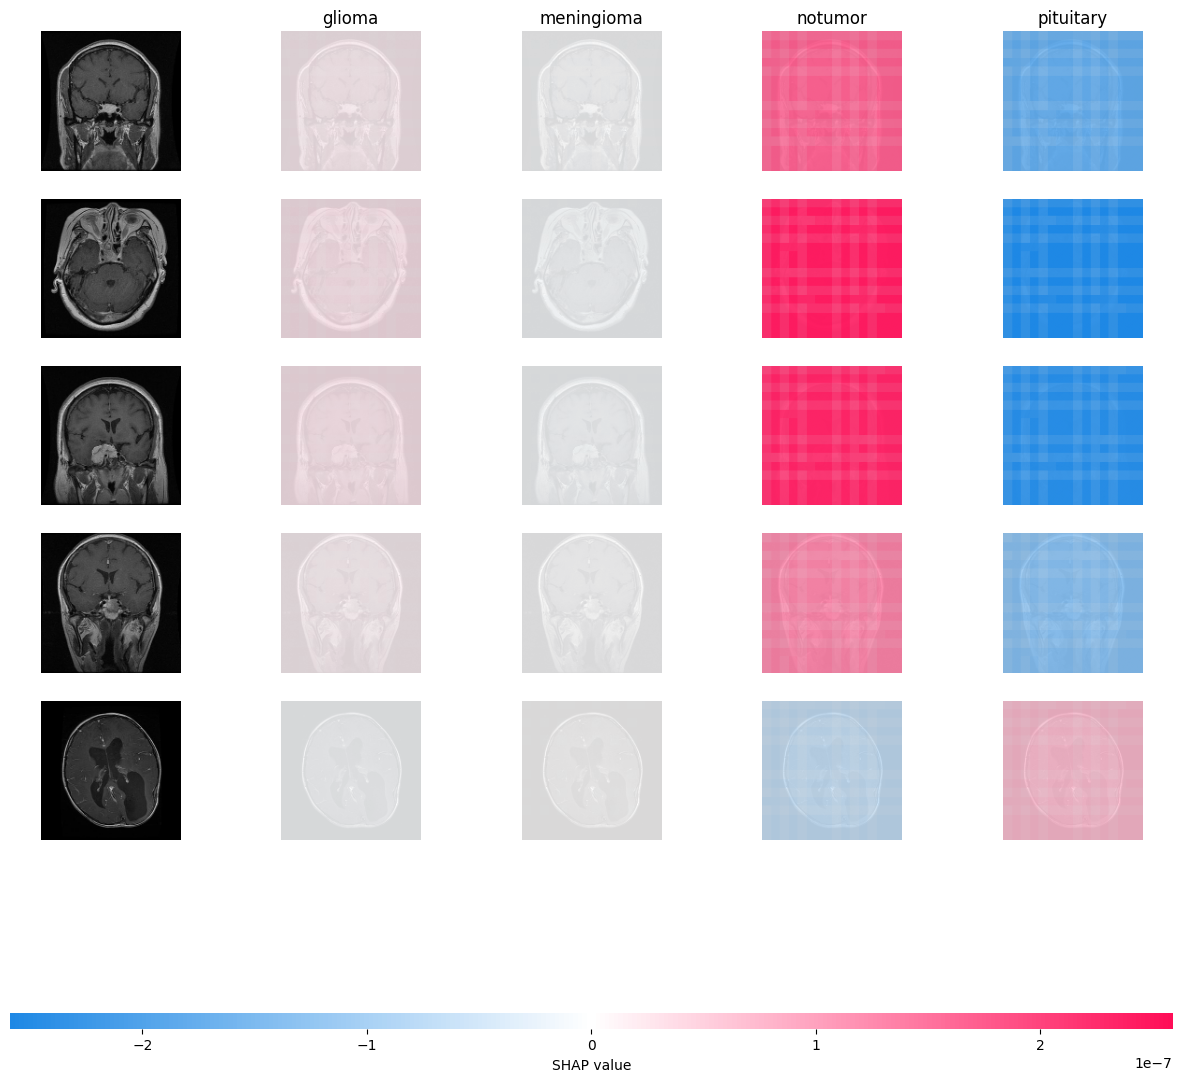

In [ ]:
# ✅ Create SHAP masker with correct syntax (use image shape, not data!)
masker = shap_Image("inpaint_telea", test_images[0].shape)

# ✅ Create SHAP explainer
explainer = shap.Explainer(model, masker, output_names=labels)

# ✅ Compute SHAP values
shap_values = explainer(test_images)

# ✅ Plot SHAP image explanations
shap.image_plot(shap_values, test_images)

In [ ]:
# === 9. Predict and Explain a Specific Image ===
from tensorflow.keras.preprocessing import image

img_path = '/content/drive/MyDrive/Brain tumar/Testing/meningioma/Te-me_0026.jpg'
img = cv2.imread(img_path)
img = cv2.resize(img, (150,150))
img = img / 255.0
img_array = img.reshape(1, 150, 150, 3)


In [ ]:
# Predict class
prediction = model.predict(img_array)
predicted_label = labels[np.argmax(prediction)]
print("Predicted Tumor Type:", predicted_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predicted Tumor Type: pituitary


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:55, 55.26s/it]               


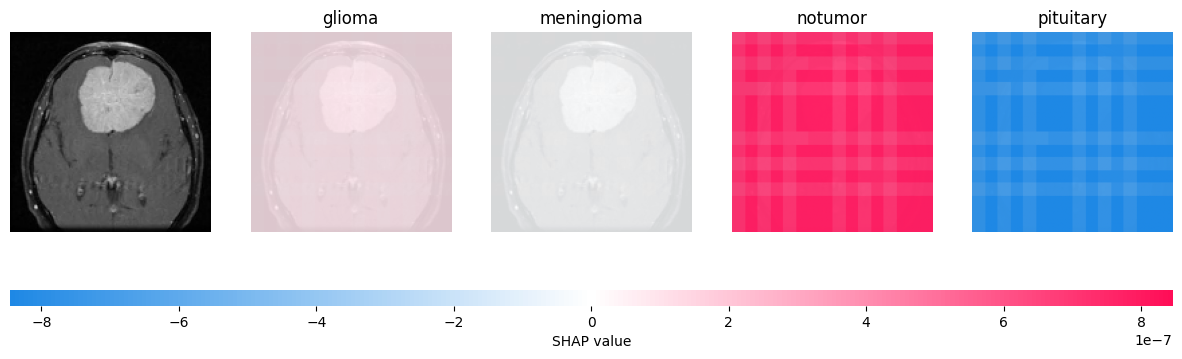

In [ ]:
# === SHAP explanation for this image ===
import shap
from shap.maskers import Image as shap_Image

# Step 1: Define the masker correctly — use "inpaint_telea" and the image shape
masker = shap_Image("inpaint_telea", img_array[0].shape)  # shape: (150, 150, 3)

# Step 2: Create the SHAP explainer
explainer_single = shap.Explainer(model, masker, output_names=labels)

# Step 3: Compute SHAP values for the single image
shap_value_single = explainer_single(img_array)

# Step 4: Plot SHAP explanation
shap.image_plot(shap_value_single, img_array)
